In [2]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_parquet("../data/processed/pfas_acs_zcta_month.parquet")

In [4]:
contain_pfas = df[df['any_detection'] == True] 
contain_pfas

,zcta,month,mean_result_ngL,n_records,n_detections,n_systems,n_contaminants,pws_names,state,any_detection,...,renter_occupied,pct_below_poverty,pct_white_nh,pct_black_nh,pct_asian_nh,pct_amerind_nh,pct_hispanic,pct_nonwhite,pct_renter,city
7,00612,2025-01-01,6.466667,319,3,1,29,ARECIBO URBANO,PR,True,...,9103.0,40.837773,0.397041,0.081650,0.012808,0.000000,99.282764,99.602959,38.838638,Arecibo
13,00637,2024-07-01,5.700000,58,1,1,29,"SABANA GRANDE, PR",PR,True,...,1801.0,44.548847,0.843384,0.000000,0.043699,0.000000,99.034260,99.156616,23.838518,Sabana Grande
18,00638,2023-07-01,6.525000,29,4,1,29,CIDRA URBANO,PR,True,...,1724.0,57.824109,0.419299,0.000000,0.000000,0.000000,99.580701,99.580701,29.101958,Ciales
19,00638,2023-10-01,5.266667,29,3,1,29,CIDRA URBANO,PR,True,...,1724.0,57.824109,0.419299,0.000000,0.000000,0.000000,99.580701,99.580701,29.101958,Ciales
20,00638,2024-01-01,7.000000,29,1,1,29,CIDRA URBANO,PR,True,...,1724.0,57.824109,0.419299,0.000000,0.000000,0.000000,99.580701,99.580701,29.101958,Ciales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100653,99775,2024-07-01,5.787500,54,8,2,29,COLLEGE UTILITIES CORPORATION; GOLDEN HEART UT...,AK,True,...,136.0,0.000000,43.281471,6.364922,26.025460,3.960396,7.072136,56.718529,100.000000,Fairbanks
100654,99775,2024-12-01,4.050000,29,2,1,29,COLLEGE UTILITIES CORPORATION,AK,True,...,136.0,0.000000,43.281471,6.364922,26.025460,3.960396,7.072136,56.718529,100.000000,Fairbanks
100655,99775,2025-01-01,5.000000,29,1,1,29,GOLDEN HEART UTILITIES,AK,True,...,136.0,0.000000,43.281471,6.364922,26.025460,3.960396,7.072136,56.718529,100.000000,Fairbanks
100658,99790,2024-07-01,5.300000,29,4,1,29,GOLDEN HEART UTILITIES,AK,True,...,0.0,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Fairbanks


In [5]:
#zcta/cities with the most average PFAS contamination
contain_pfas.groupby(['zcta', 'city'])[['mean_result_ngL']].mean().sort_values(by='mean_result_ngL', ascending=False).head(10)

,,mean_result_ngL
zcta,city,
55071,Saint Paul Park,1225.000000
44118,Cleveland,400.000000
55128,Saint Paul,285.990556
96950,Saipan,257.999126
85258,Scottsdale,171.150000
98027,Issaquah,170.130000
56601,Bemidji,160.000000
52736,Unknown city,137.710000
85718,Tucson,134.700000


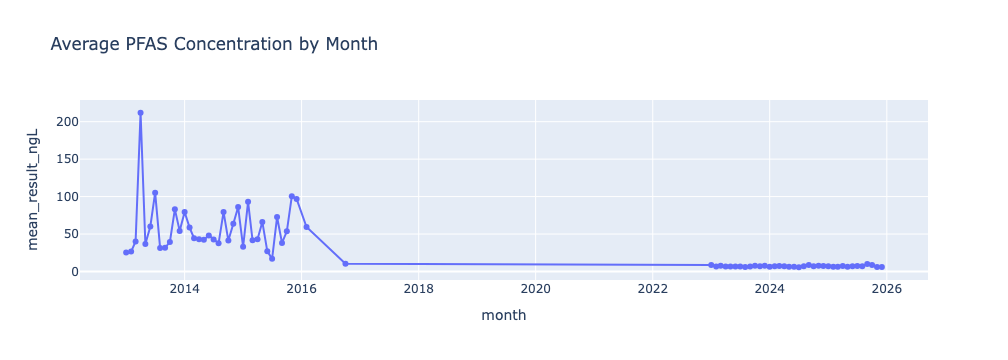

In [51]:
#timeline of PFAS contamination (U.S.)
import plotly.express as px

contain_pfas_grouped = (
    contain_pfas
    .groupby("month")["mean_result_ngL"]
    .mean()
    .reset_index()
)

fig = px.line(
    contain_pfas_grouped,
    x="month",
    y="mean_result_ngL",
    markers=True,
    title="Average PFAS Concentration by Month"
)

fig.show()

In [254]:
contain_pfas.groupby('year')[['zcta']].agg('count').rename(columns={"zcta": "Total Sample Size"})

,Total Sample Size
year,
2013,768
2014,1094
2015,713
2016,2
2023,12993
2024,15014
2025,5604


In [47]:
#Possible explanations for the graph:
#earlier years had sampled fewer locations

contain_pfas['year'] = contain_pfas['month'].dt.year


years = [2013, 2014, 2015, 2016, 2023, 2024, 2025]

yearly_zcta_data = {
    'Year': years,
    'Unique ZCTA Count': [
        len(pd.unique(contain_pfas[contain_pfas['month'].dt.year == year]['zcta'])) 
        for year in years
    ]
}

zcta_summary_df = pd.DataFrame(yearly_zcta_data)

zcta_summary_df
#The sampling may have targeted known or suspected contamination hotspots, leading to higher
#average contamination hotspots. From 2023 onwards, monitoring included more locations, which
#pulled down the average

#note: UCMR 3 from 2013-2015 and UCMR 4 from 2016-2022 (did not monitor PFAS nationally
#and 2023-2025 UCMR 5


/var/folders/g_/79rplc813f145vr0_bmjtlpr0000gn/T/ipykernel_21940/2180055141.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contain_pfas['year'] = contain_pfas['month'].dt.year


,Year,Unique ZCTA Count
0,2013,397
1,2014,597
2,2015,420
3,2016,2
4,2023,5137
5,2024,6330
6,2025,2831


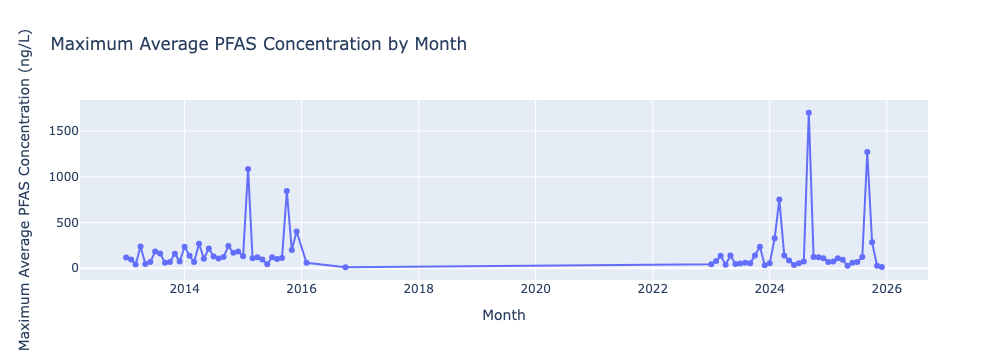

In [54]:
#
contain_pfas_grouped_max = (
    contain_pfas
    .groupby("month")["mean_result_ngL"]
    .max()
    .reset_index()
)

fig = px.line(
    contain_pfas_grouped_max,
    x="month",
    y="mean_result_ngL",
    markers=True,
    title="Maximum Average PFAS Concentration by Month"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Maximum Average PFAS Concentration (ng/L)"
)

fig.show()


In [171]:
#grouping by zcta codes 

zcta_pfas_with_demog = contain_pfas.groupby('zcta').agg({'mean_result_ngL': 'mean', 
                                                         'n_records': 'sum', 
                                                         'n_detections': 'sum', 
                                                         'n_contaminants': 'max', #only test for a max of 29 contaminants 
                                                         'median_hh_income': 'first', 
                                                         'median_age': 'mean',
                                                         'pct_below_poverty': 'first',
                                                         'pct_white_nh': 'first',
                                                         'pct_black_nh': 'first',
                                                         'pct_asian_nh': 'first',
                                                         'pct_amerind_nh':'first',
                                                         'pct_hispanic': 'first',
                                                         'pct_nonwhite': 'first',
                                                         'pct_renter': 'first'}).sort_values(by='mean_result_ngL', ascending = False)
zcta_pfas_with_demog

,mean_result_ngL,n_records,n_detections,n_contaminants,median_hh_income,median_age,pct_below_poverty,pct_white_nh,pct_black_nh,pct_asian_nh,pct_amerind_nh,pct_hispanic,pct_nonwhite,pct_renter
zcta,,,,,,,,,,,,,,
55071,1225.000000,58,2,29,98945.0,41.1,5.270410,77.509902,2.548648,5.579473,0.000000,11.520579,22.490098,20.428266
44118,400.000000,6,1,6,76328.0,33.9,15.683206,57.107133,33.392755,3.117185,0.079229,2.059967,42.892867,38.783410
55128,285.990556,280,26,29,89642.0,41.0,6.249566,66.619451,8.319226,12.855415,0.310935,6.128865,33.380549,22.017729
96950,257.999126,1053,55,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
85258,171.150000,41,9,29,105171.0,55.3,10.801147,84.622316,2.691584,3.667137,0.082276,6.170663,15.377684,26.246288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21213,3.000000,87,1,29,50031.0,38.0,24.581831,5.939529,86.273807,0.218787,0.272587,4.472580,94.060471,46.821759
30917,3.000000,58,1,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
86404,3.000000,29,1,29,67528.0,60.2,13.284741,82.561221,0.174918,0.800382,0.376338,12.482773,17.438779,17.568328


In [210]:
city_pfas_with_demog = contain_pfas.groupby('city').agg({'mean_result_ngL': 'mean', 
                                                         'n_records': 'sum', 
                                                         'n_detections': 'sum', 
                                                         'n_contaminants': 'max', #only test for a max of 29 contaminants 
                                                         'median_hh_income': 'mean', 
                                                         'median_age': 'mean',
                                                         'pct_below_poverty': 'mean',
                                                         'pct_white_nh': 'mean',
                                                         'pct_black_nh': 'mean',
                                                         'pct_asian_nh': 'mean',
                                                         'pct_amerind_nh':'mean',
                                                         'pct_hispanic': 'mean',
                                                         'pct_nonwhite': 'mean',
                                                         'pct_renter': 'mean'}).sort_values(by='mean_result_ngL', ascending = False)
city_pfas_with_demog

,mean_result_ngL,n_records,n_detections,n_contaminants,median_hh_income,median_age,pct_below_poverty,pct_white_nh,pct_black_nh,pct_asian_nh,pct_amerind_nh,pct_hispanic,pct_nonwhite,pct_renter
city,,,,,,,,,,,,,,
Saint Paul Park,1225.000000,58,2,29,98945.0,41.1,5.270410,77.509902,2.548648,5.579473,0.000000,11.520579,22.490098,20.428266
Saipan,257.999126,1053,55,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bemidji,160.000000,6,2,6,69782.0,36.0,13.587995,80.383285,1.135447,0.711816,7.458213,2.752161,19.616715,33.091684
Vail,134.700000,783,5,29,121647.0,39.7,5.128774,66.957208,4.370756,2.709616,0.555819,18.806253,33.042792,6.742516
Christine,119.000000,116,1,29,47708.0,35.2,14.010989,0.000000,0.000000,0.000000,0.000000,100.000000,100.000000,29.365079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Towson,3.000000,174,2,29,95772.5,37.1,14.266559,69.681285,15.117528,4.518344,0.128794,5.983402,30.318715,45.620218
Fort Howard,3.000000,87,1,29,117222.0,36.0,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Makoti,3.000000,29,1,29,74609.0,57.5,6.790123,96.296296,0.000000,0.000000,1.234568,2.469136,3.703704,14.117647


In [242]:
state_pfas_with_demog = contain_pfas.groupby('state').agg({'mean_result_ngL': 'mean', 
                                                         'n_records': 'sum', 
                                                         'n_detections': 'sum', 
                                                         'n_contaminants': 'max', #only test for a max of 29 contaminants 
                                                         'median_hh_income': 'mean', 
                                                         'median_age': 'mean',
                                                         'pct_below_poverty': 'mean',
                                                         'pct_white_nh': 'mean',
                                                         'pct_black_nh': 'mean',
                                                         'pct_asian_nh': 'mean',
                                                         'pct_amerind_nh':'mean',
                                                         'pct_hispanic': 'mean',
                                                         'pct_nonwhite': 'mean',
                                                         'pct_renter': 'mean'}).sort_values(by='mean_result_ngL', ascending = False)
state_pfas_with_demog

,mean_result_ngL,n_records,n_detections,n_contaminants,median_hh_income,median_age,pct_below_poverty,pct_white_nh,pct_black_nh,pct_asian_nh,pct_amerind_nh,pct_hispanic,pct_nonwhite,pct_renter
state,,,,,,,,,,,,,,
MP,257.999126,1053,55,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DE,25.591050,27478,2833,29,92101.298893,43.663082,10.449977,58.475693,20.702561,4.922294,0.114200,11.525130,41.524307,29.140735
AZ,25.308900,132977,3775,29,86115.528133,39.712594,11.483272,56.382882,4.630619,3.911967,1.897261,28.542216,43.617118,34.489217
MN,25.284976,24814,1007,29,91718.745283,36.774651,12.476727,68.209987,11.537230,6.979902,0.455131,7.582991,31.790013,38.677750
ME,24.593365,1648,113,29,69245.133333,47.185294,13.173232,92.983070,0.589231,0.766492,0.063523,2.072700,7.016930,23.406021
GU,23.981204,19486,1384,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NY,23.671450,1173593,18244,29,127839.984078,43.662002,6.571738,70.027941,5.167547,4.547461,0.209053,16.776573,29.972059,18.373616
AS,15.433333,2060,3,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CO,15.282657,18373,1783,29,110943.940476,36.891667,6.723423,63.258464,3.927825,4.303761,0.265126,22.990748,36.741536,24.141909


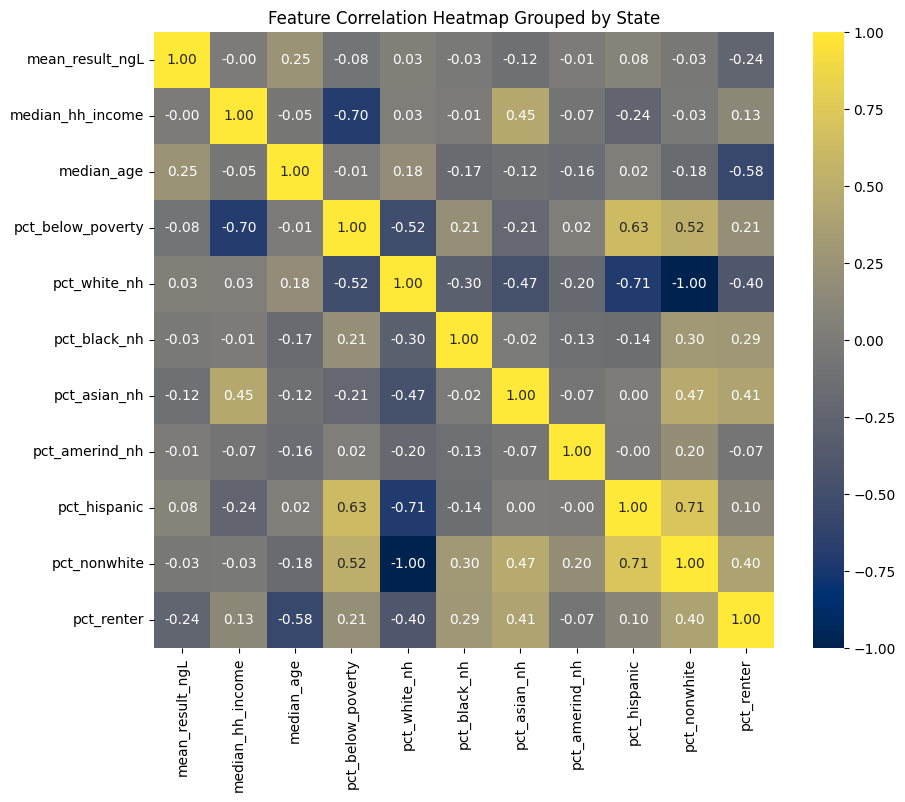

In [255]:
import seaborn as sns 
import matplotlib.pyplot as plt

corr_matrix = state_pfas_with_demog.drop(['n_records', 'n_detections', 'n_contaminants'], axis=1).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='cividis', fmt='.2f', vmin=-1, vmax=1) #most accessible colors
plt.title("Feature Correlation Heatmap Grouped by State")
plt.show()

/var/folders/g_/79rplc813f145vr0_bmjtlpr0000gn/T/ipykernel_21940/564149215.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contain_pfas['log_pfas'] = np.log(contain_pfas['mean_result_ngL'])


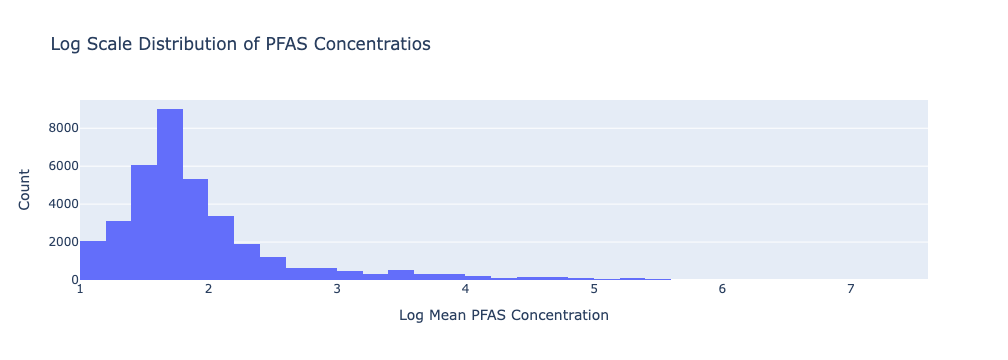

In [256]:
contain_pfas['log_pfas'] = np.log(contain_pfas['mean_result_ngL'])

fig = px.histogram(
    contain_pfas,
    x="log_pfas", 
    nbins = 45,
    title = "Log Scale Distribution of PFAS Concentratios"
)
fig.update_layout(
    xaxis_title="Log Mean PFAS Concentration",
    yaxis_title="Count"
)

/var/folders/g_/79rplc813f145vr0_bmjtlpr0000gn/T/ipykernel_21940/1197465109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contain_pfas["high_contam"] = contain_pfas["mean_result_ngL"] > 10


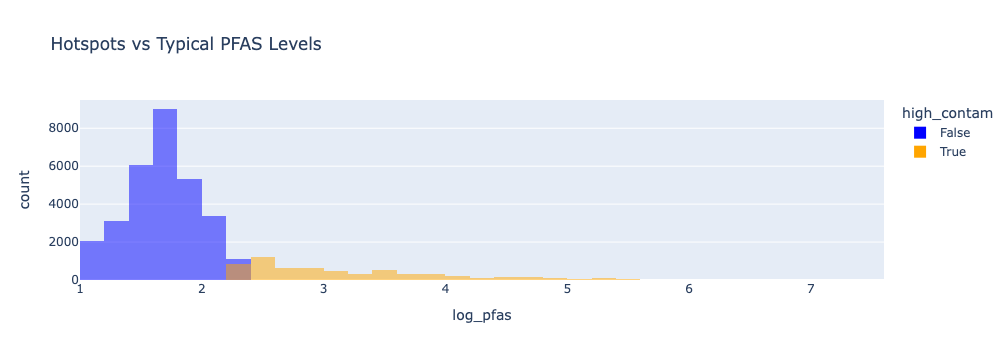

In [257]:
contain_pfas["high_contam"] = contain_pfas["mean_result_ngL"] > 10


px.histogram(
    contain_pfas,
    x="log_pfas",
    nbins=50,
    color="high_contam",
    barmode='overlay',
    color_discrete_map={
        True: 'orange',  # Use boolean True as the key
        False: 'blue'    # Use boolean False as the key
    },
    title="Hotspots vs Typical PFAS Levels", 
    
)

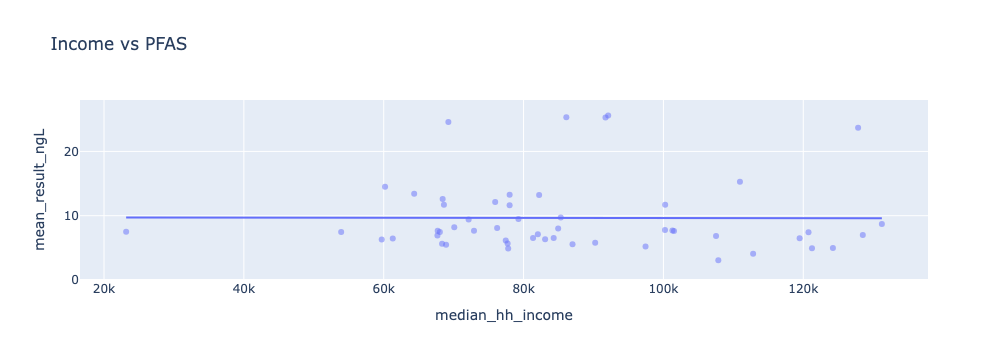

In [258]:
fig = px.scatter(
    state_pfas_with_demog,
    x="median_hh_income",
    y="mean_result_ngL",
    title="Income vs PFAS",
    trendline="ols",
    opacity=0.5
)
fig.update_yaxes(range=[0, 28])

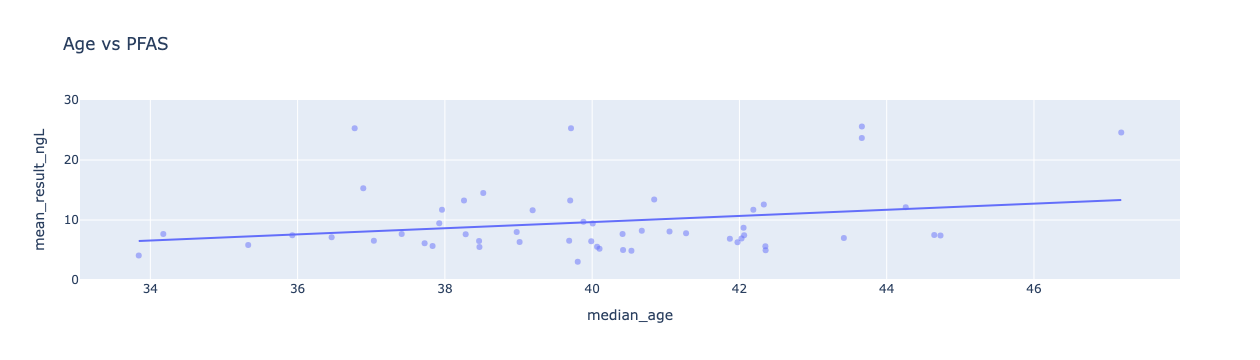

In [260]:
fig = px.scatter(
    state_pfas_with_demog,
    x="median_age",
    y="mean_result_ngL",
    title="Age vs PFAS",
    trendline="ols",
    opacity=0.5
)
fig.update_yaxes(range=[0, 30])

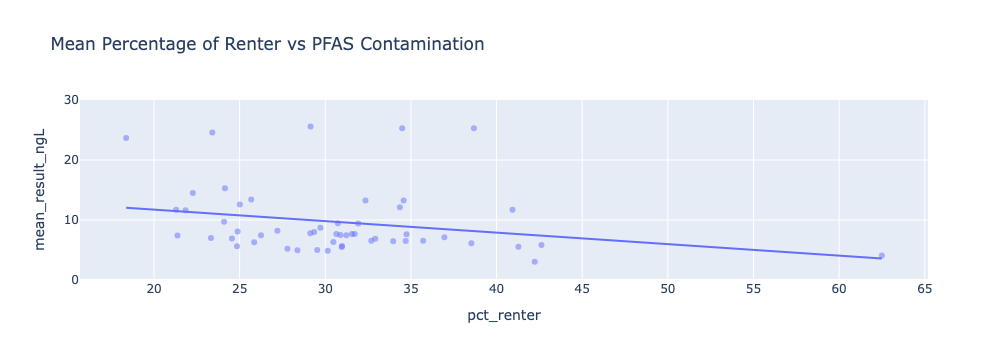

In [225]:
fig = px.scatter(
    state_pfas_with_demog,
    x="pct_renter",
    y="mean_result_ngL",
    title="Mean Percentage of Renter vs PFAS Contamination",
    trendline="ols",
    opacity=0.5
)
fig.update_yaxes(range=[0, 30])